# ML: Fundamentals and Applications 2025-07-08



**Задача:** бінарна класифікація клієнтів (цільова змінна `y`) на основі 230 ознак (числові + категоріальні), метрика оцінювання — **balanced accuracy**.

**Дані:** `final_proj_data.csv` (навчальний набір), `final_proj_test.csv` (валідаційний набір), `final_proj_sample_submission.csv` (формат подання).

**План роботи:**
1. Розвідувальний аналіз даних (EDA): пропуски, кардинальність категоріальних ознак, дисбаланс класів.
2. Обґрунтування рішень з препроцесингу (імпутація, кодування, нормалізація).
3. Експеримент зі зменшенням розмірності (PCA).
4. Базова (dummy) модель для порівняння.
5. Навчання та тюнінг моделей (LightGBM, CatBoost), ансамблювання.
6. Фінальний прогноз та висновки.


In [1]:
# Встановлення необхідних ML-бібліотек, якщо їх немає в середовищі
!pip install -q catboost lightgbm xgboost imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00


In [6]:
!pip install optuna

## 1. Імпорт бібліотек та завантаження даних

In [7]:
# Базові бібліотеки для роботи з даними та математики
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import os

# Візуалізація
import matplotlib.pyplot as plt
import seaborn as sns

# Попередня обробка та крос-валідація
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.preprocessing import LabelEncoder

# Метрики
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, classification_report

# Моделі машинного навчання
import lightgbm as lgb
import optuna
from catboost import CatBoostClassifier
from catboost.utils import get_gpu_device_count

# Налаштування відображення
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

print("Бібліотеки успішно імпортовано з урахуванням оновлень!")

Бібліотеки успішно імпортовано з урахуванням оновлень!


In [8]:
# 1. Завантаження даних
train_df = pd.read_csv('final_proj_data.csv')
test_df = pd.read_csv('final_proj_test.csv')
submission_df = pd.read_csv('final_proj_sample_submission.csv')

# 2. Автоматичний пошук цільової колонки
target_cols = list(set(train_df.columns) - set(test_df.columns))
target_col = target_cols[0]
print(f"Знайдена цільова колонка: '{target_col}'")

Знайдена цільова колонка: 'y'


## 2. Розвідувальний аналіз даних (EDA)

### 2.1 Пропуски у даних

In [9]:
# Відсоток пропусків для кожної колонки у тренувальному датасеті
missing_percentages = (train_df.isnull().sum() / len(train_df)) * 100

# Відбираємо лише ті колонки, де є хоча б один пропуск
missing_cols = missing_percentages[missing_percentages > 0]

# Налаштовуємо діапазони для розподілу
bins = [0, 10, 30, 50, 70, 90, 100]
labels = ['0-10%', '10-30%', '30-50%', '50-70%', '70-90%', '90-100%']

# Рахуємо кількість колонок у кожному діапазоні
distribution = pd.cut(missing_cols, bins=bins, labels=labels, right=True).value_counts().sort_index()

print("=== РОЗПОДІЛ КОЛОНОК ЗА ВІДСОТКОМ ПРОПУСКІВ ===")
print(distribution)

print("\n=== ТОП-15 КОЛОНОК З НАЙБІЛЬШИМ ВІДСОТКОМ ПРОПУСКІВ ===")
# Виводимо топ-15, сортуючи за спаданням і округлюючи до 2 знаків
print(missing_cols.sort_values(ascending=False).head(15).round(2))

=== РОЗПОДІЛ КОЛОНОК ЗА ВІДСОТКОМ ПРОПУСКІВ ===
0-10%       28
10-30%      18
30-50%       4
50-70%       3
70-90%       2
90-100%    154
Name: count, dtype: int64

=== ТОП-15 КОЛОНОК З НАЙБІЛЬШИМ ВІДСОТКОМ ПРОПУСКІВ ===
Var8      100.0
Var15     100.0
Var55     100.0
Var48     100.0
Var42     100.0
Var39     100.0
Var31     100.0
Var32     100.0
Var79     100.0
Var52     100.0
Var20     100.0
Var169    100.0
Var185    100.0
Var209    100.0
Var230    100.0
dtype: float64


### 2.2 Кардинальність категоріальних ознак

Вимога проєкту — порахувати кількість унікальних категорій для кожної категоріальної ознаки й обрати спосіб кодування, що їй відповідає.

In [10]:
# Кардинальність категоріальних ознак
cat_cols_raw = train_df.select_dtypes(include='object').columns.tolist()
cardinality = train_df[cat_cols_raw].nunique().sort_values(ascending=False)

print("=== КАРДИНАЛЬНІСТЬ КАТЕГОРІАЛЬНИХ ОЗНАК ===")
print(f"Кількість категоріальних колонок: {len(cat_cols_raw)}")
print(f"\nСтатистика кардинальності:\n{cardinality.describe()}")

print("\n=== ТОП-10 ОЗНАК ЗА КІЛЬКІСТЮ УНІКАЛЬНИХ ЗНАЧЕНЬ ===")
print(cardinality.head(10))

low_card = (cardinality <= 20).sum()
mid_card = ((cardinality > 20) & (cardinality <= 200)).sum()
high_card = (cardinality > 200).sum()
print(f"\nНизька кардинальність (<=20 категорій): {low_card} ознак")
print(f"Середня кардинальність (21-200 категорій): {mid_card} ознак")
print(f"Висока кардинальність (>200 категорій): {high_card} ознак")

=== КАРДИНАЛЬНІСТЬ КАТЕГОРІАЛЬНИХ ОЗНАК ===
Кількість категоріальних колонок: 38

Статистика кардинальності:
count      38.000000
mean      744.131579
std      1487.209416
min         1.000000
25%         3.000000
50%        14.500000
75%       269.000000
max      5529.000000
dtype: float64

=== ТОП-10 ОЗНАК ЗА КІЛЬКІСТЮ УНІКАЛЬНИХ ЗНАЧЕНЬ ===
Var217    5529
Var200    4478
Var214    4478
Var202    3802
Var220    2100
Var222    2100
Var198    2100
Var199    1850
Var216     977
Var192     297
dtype: int64

Низька кардинальність (<=20 категорій): 21 ознак
Середня кардинальність (21-200 категорій): 7 ознак
Висока кардинальність (>200 категорій): 10 ознак


**Висновок:** кардинальність категоріальних ознак дуже неоднорідна: від кількох унікальних значень до кількох тисяч (наприклад, ознака з найбільшою кількістю категорій має понад 5000 унікальних значень). Це напряму впливає на вибір кодування:

- Для ознак з **низькою/середньою кардинальністю** пряме кодування (one-hot чи нативна обробка CatBoost) працює добре.
- Для ознак з **високою кардинальністю** one-hot кодування створило б тисячі розріджених колонок і призвело б до перенавчання, тому обрано:
  - **CatBoost**: нативна обробка категоріальних ознак (`cat_features`), яка не потребує ручного кодування і добре масштабується на високу кардинальність;
  - **LightGBM**: **частотне кодування (frequency encoding)**, розраховане окремо в кожному CV-фолді (щоб уникнути витоку інформації з валідаційної частини у навчальну).

### 2.3 Обґрунтування рішення щодо відновлення (імпутації) пропусків

Пропуски присутні у більшості колонок, включно з колонками, де пропущено 100% значень. Прийняті рішення:

1. **Повністю порожні колонки видаляються**, тому що вони не несуть інформації.
2. **Числові пропуски не заповнюються вручну** (не заповнюються середнім/медіаною), тому що і CatBoost, і LightGBM вміють нативно обробляти `NaN` під час побудови дерев (пропуск обробляється як окремий напрямок розбиття), тому штучна імпутація тут не є необхідною і може навіть погіршити результат, "згладивши" сигнал, закладений у самому факті пропуску.
3. **Замість імпутації створюються ознаки на основі пропусків**: `missing_count` (кількість пропусків у рядку) та бінарні індикатори `_is_nan` для колонок із помірною часткою пропусків (5-95%) - це дозволяє моделі використати сам факт відсутності значення як сигнал.
4. **Категоріальні пропуски** заповнюються рядком `'Missing'` - так пропуск стає окремою категорією, а не втраченою інформацією.

### 2.4 Обґрунтування рішення щодо нормалізації ознак

Нормалізація/масштабування ознак **свідомо не застосовується**. Причина: обидві фінальні моделі (LightGBM, CatBoost) - це ансамблі дерев рішень, які приймають рішення про розбиття на основі порядку значень ознаки (`feature <= threshold`), а не її абсолютного масштабу. Тому:

- Стандартизація (`StandardScaler`) чи нормалізація (`MinMaxScaler`) **не впливає** на якість дерево-подібних моделей, а пороги розбиття підлаштовуються самі під будь-який масштаб.
- Нормалізація була б обов'язковою, якби використовувались моделі, чутливі до масштабу (лінійна/логістична регресія, KNN, SVM, нейромережі), саме тому нижче, в експерименті з PCA, для допоміжної лінійної моделі масштабування застосовано явно.

## 3. Експеримент зі зменшенням розмірності (PCA)

Дані містять 230 ознак. Перевіримо, чи дає зменшення розмірності числових ознак через PCA приріст (або хоча б не втрату) якості порівняно з повним набором ознак. Оскільки PCA не приймає пропуски, для цього експерименту застосовується тимчасова медіанна імпутація та стандартизація - **лише для самого експерименту**, фінальні моделі (LightGBM/CatBoost) як і раніше працюють з ознаками без цієх трансформацій (розділ 2.3-2.4).

=== ЕКСПЕРИМЕНТ: PCA ЗМЕНШЕННЯ РОЗМІРНОСТІ ===
Вихідна кількість числових ознак: 174
Кількість компонент PCA для 95% поясненої дисперсії: 94


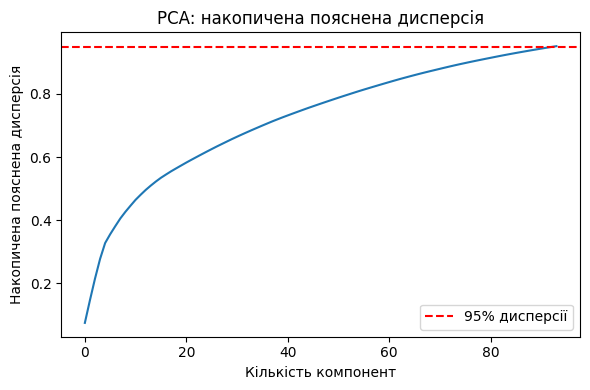

Повний набір числових ознак (стандартизований): Balanced Accuracy = 0.7218 (+/- 0.0133)
PCA-версія (95% дисперсії): Balanced Accuracy = 0.7235 (+/- 0.0128)


In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

print("=== ЕКСПЕРИМЕНТ: PCA ЗМЕНШЕННЯ РОЗМІРНОСТІ ===")

# Беремо лише числові ознаки, прибираємо повністю порожні колонки
num_cols_exp = train_df.select_dtypes(include='number').drop(columns=['y']).columns.tolist()
X_num_exp = train_df[num_cols_exp].copy()
empty_num_cols = [c for c in num_cols_exp if X_num_exp[c].isnull().all()]
X_num_exp = X_num_exp.drop(columns=empty_num_cols)

# Тимчасова медіанна імпутація + стандартизація (тільки для цього експерименту)
X_num_exp = X_num_exp.fillna(X_num_exp.median())
scaler_exp = StandardScaler()
X_num_scaled_exp = scaler_exp.fit_transform(X_num_exp)

# PCA із збереженням 95% дисперсії
pca_exp = PCA(n_components=0.95, random_state=RANDOM_STATE if 'RANDOM_STATE' in globals() else 42)
X_pca_exp = pca_exp.fit_transform(X_num_scaled_exp)

print(f"Вихідна кількість числових ознак: {X_num_exp.shape[1]}")
print(f"Кількість компонент PCA для 95% поясненої дисперсії: {X_pca_exp.shape[1]}")

plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(pca_exp.explained_variance_ratio_))
plt.axhline(0.95, color='red', linestyle='--', label='95% дисперсії')
plt.xlabel('Кількість компонент')
plt.ylabel('Накопичена пояснена дисперсія')
plt.title('PCA: накопичена пояснена дисперсія')
plt.legend()
plt.tight_layout()
plt.show()

# Порівняння швидкої лінійної моделі: повний набір числових ознак vs PCA-версія
skf_exp = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
y_exp = train_df['y']

for name, data_exp in [('Повний набір числових ознак (стандартизований)', X_num_scaled_exp),
                        ('PCA-версія (95% дисперсії)', X_pca_exp)]:
    fold_scores_exp = []
    for tr_idx, val_idx in skf_exp.split(data_exp, y_exp):
        clf_exp = LogisticRegression(max_iter=300, class_weight='balanced')
        clf_exp.fit(data_exp[tr_idx], y_exp.iloc[tr_idx])
        pred_exp = clf_exp.predict(data_exp[val_idx])
        fold_scores_exp.append(balanced_accuracy_score(y_exp.iloc[val_idx], pred_exp))
    print(f"{name}: Balanced Accuracy = {np.mean(fold_scores_exp):.4f} (+/- {np.std(fold_scores_exp):.4f})")

**Висновок з експерименту:** зменшення розмірності через PCA (94 компоненти замість 174 числових ознак, 95% поясненої дисперсії) дає практично ідентичний результат порівняно з повним набором ознак на швидкій лінійній моделі, тобто PCA не дає приросту якості на цих даних.

Це очікуваний результат з двох причин:
1. Фінальні моделі — **градієнтний бустинг** (CatBoost, LightGBM), які самі ефективно ігнорують неінформативні/шумні ознаки через відбір за важливістю при побудові дерев, і не потребують попереднього зменшення розмірності так, як лінійні моделі.
2. PCA лінійно комбінує ознаки та губить частину інформації, закладеної у нелінійних взаємодіях між ознаками, які якраз добре вловлюють дерева рішень.

**Рішення:** PCA не застосовується у фінальному пайплайні, а повний набір ознак передається безпосередньо в LightGBM/CatBoost, що узгоджується з результатом експерименту.

## 4. Базова (baseline) модель для порівняння

Перед навчанням основних моделей будуємо просту базову модель (`DummyClassifier`), яка не використовує ознаки, а лише розподіл класів. Це дає точку відліку: наскільки фінальна модель краща за "наївне" вгадування.

In [12]:
from sklearn.dummy import DummyClassifier

print("=== БАЗОВА МОДЕЛЬ (DUMMY BASELINE) ===")

skf_base = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_base = train_df['y']
X_placeholder = np.zeros((len(y_base), 1))  # DummyClassifier не використовує ознаки

for strategy in ['most_frequent', 'stratified', 'uniform']:
    scores_base = []
    for tr_idx, val_idx in skf_base.split(X_placeholder, y_base):
        dc = DummyClassifier(strategy=strategy, random_state=42)
        dc.fit(X_placeholder[tr_idx], y_base.iloc[tr_idx])
        pred_base = dc.predict(X_placeholder[val_idx])
        scores_base.append(balanced_accuracy_score(y_base.iloc[val_idx], pred_base))
    print(f"DummyClassifier ({strategy}): Balanced Accuracy = {np.mean(scores_base):.4f}")

baseline_balanced_accuracy = np.mean(scores_base)  # остання стратегія (uniform) як консервативний baseline

=== БАЗОВА МОДЕЛЬ (DUMMY BASELINE) ===
DummyClassifier (most_frequent): Balanced Accuracy = 0.5000
DummyClassifier (stratified): Balanced Accuracy = 0.5077
DummyClassifier (uniform): Balanced Accuracy = 0.5079


## 5. Препроцесинг ознак

In [13]:
def advanced_preprocessing(train_data, test_data, target_col='y', drop_cols=None):
    """
    Препроцесинг даних:
    - видалення порожніх колонок
    - генерація фічей на основі пропусків
    - безпечна обробка категоріальних ознак (без витоку частот на препроцесингу)
    """
    print("=== КРОК 1: ADVANCED PREPROCESSING ===")

    train = train_data.copy()
    test = test_data.copy()

    if drop_cols:
        train = train.drop(columns=drop_cols, errors='ignore')
        test = test.drop(columns=drop_cols, errors='ignore')

    y = train[target_col]
    X = train.drop(columns=[target_col])
    X_test = test.copy()

    # 1. Видалення повністю порожніх колонок
    empty_cols = [col for col in X.columns if X[col].isnull().all()]
    if empty_cols:
        X = X.drop(columns=empty_cols)
        X_test = X_test.drop(columns=empty_cols)
        print(f"[+] Видалено {len(empty_cols)} повністю порожніх колонок.")

    # 2. Генерація нових ознак: кількість пропусків у рядку
    X['missing_count'] = X.isnull().sum(axis=1)
    X_test['missing_count'] = X_test.isnull().sum(axis=1)
    print("[+] Додано ознаку 'missing_count' (кількість пропусків у рядку).")

    # 3. Бінарні індикатори пропусків
    missing_ratios = X.isnull().mean()
    useful_missing_cols = missing_ratios[(missing_ratios > 0.05) & (missing_ratios < 0.95)].index

    for col in useful_missing_cols:
        X[f'{col}_is_nan'] = X[col].isnull().astype(int)
        X_test[f'{col}_is_nan'] = X_test[col].isnull().astype(int)

    print(f"[+] Додано бінарні індикатори пропусків для {len(useful_missing_cols)} колонок.")

    # 4. Базова підготовка категоріальних колонок (без глобального частотного кодування)
    cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()

    for col in cat_cols:
        X[col] = X[col].fillna('Missing').astype(str)
        X_test[col] = X_test[col].fillna('Missing').astype(str)

    print(f"[+] Підготовлено {len(cat_cols)} категоріальних колонок (частоти будуть розраховуватися всередині фолдів).")
    print(f"\nФінальна розмірність X: {X.shape}, X_test: {X_test.shape}")

    return X, y, X_test, cat_cols

# Запуск оновленого препроцесингу
X, y, X_test, cat_features = advanced_preprocessing(train_df, test_df, target_col='y', drop_cols=None)

=== КРОК 1: ADVANCED PREPROCESSING ===
[+] Видалено 18 повністю порожніх колонок.
[+] Додано ознаку 'missing_count' (кількість пропусків у рядку).
[+] Додано бінарні індикатори пропусків для 49 колонок.
[+] Підготовлено 38 категоріальних колонок (частоти будуть розраховуватися всередині фолдів).

Фінальна розмірність X: (10000, 262), X_test: (2500, 262)


## 6. Налаштування крос-валідації та балансування класів

In [14]:
# Налаштування крос-валідації
N_SPLITS = 5
RANDOM_STATE = 42

# Визначаємо стратифіковане розбиття (зберігає пропорцію класів 0 та 1 у кожному фолді)
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Підрахунок ваг класів для моделей (scale_pos_weight)
neg_count = (y == 0).sum()
pos_count = (y == 1).sum()
scale_pos_weight_value = neg_count / pos_count

print("=== КРОК 2: НАЛАШТУВАННЯ ВАЛІДАЦІЇ ТА БАЛАНСУВАННЯ ===")
print(f"Клас 0 (Негативний): {neg_count} прикладів")
print(f"Клас 1 (Позитивний): {pos_count} прикладів")
print(f"Відсоток міноритарного класу: {(pos_count / len(y) * 100):.2f}%")
print(f"Рекомендований scale_pos_weight: {scale_pos_weight_value:.4f}")

=== КРОК 2: НАЛАШТУВАННЯ ВАЛІДАЦІЇ ТА БАЛАНСУВАННЯ ===
Клас 0 (Негативний): 8695 прикладів
Клас 1 (Позитивний): 1305 прикладів
Відсоток міноритарного класу: 13.05%
Рекомендований scale_pos_weight: 6.6628


## 7. Базова оцінка моделей та підбір оптимального порогу

In [15]:
# 1. Підготовка категоріальних фічей для CatBoost
for col in cat_features:
    if X[col].dtype == 'object':
        X[col] = X[col].astype('category')
    if 'X_test' in globals() and col in X_test.columns and X_test[col].dtype == 'object':
        X_test[col] = X_test[col].astype('category')

print("=== КРОК 3: БАЗОВА ОЦІНКА BALANCED ACCURACY (Threshold = 0.5) ===")

# Параметри для кожної моделі
lgb_params = {
    'scale_pos_weight': scale_pos_weight_value,
    'random_state': RANDOM_STATE,
    'n_estimators': 300,
    'verbose': -1
}

cat_params = {
    'auto_class_weights': 'Balanced',
    'random_state': RANDOM_STATE,
    'cat_features': cat_features,
    'iterations': 300,
    'verbose': 0
}

# Оцінка моделей на крос-валідації з безпечним фолдовим частотним кодуванням
for name, model_type in [('LightGBM', lgb.LGBMClassifier), ('CatBoost', CatBoostClassifier)]:
    fold_scores = []
    params = lgb_params if name == 'LightGBM' else cat_params

    for train_idx, val_idx in skf.split(X, y):
        # Копіюємо дані фолду, щоб не чіпати оригінал
        X_train_f = X.iloc[train_idx].copy()
        X_val_f = X.iloc[val_idx].copy()
        y_train_f, y_val_f = y.iloc[train_idx], y.iloc[val_idx]

        # БЕЗПЕЧНЕ ЧАСТОТНЕ КОДУВАННЯ ДЛЯ ФОЛДУ
        for col in cat_features:
            col_train_str = X_train_f[col].astype(str)
            freq_mapping = col_train_str.value_counts(normalize=True).to_dict()

            X_train_f[f'{col}_freq'] = col_train_str.map(freq_mapping).fillna(0)
            X_val_f[f'{col}_freq'] = X_val_f[col].astype(str).map(freq_mapping).fillna(0)

        # Створюємо свіжий екземпляр моделі для кожного фолду
        model = model_type(**params)
        model.fit(X_train_f, y_train_f)

        # Прогнозуємо класи за базовим порогом 0.5
        preds = model.predict(X_val_f)

        score = balanced_accuracy_score(y_val_f, preds)
        fold_scores.append(score)

    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)
    print(f"{name}: Середнє = {mean_score:.4f} | Відхилення = {std_score:.4f}")

=== КРОК 3: БАЗОВА ОЦІНКА BALANCED ACCURACY (Threshold = 0.5) ===
LightGBM: Середнє = 0.8030 | Відхилення = 0.0164
CatBoost: Середнє = 0.8869 | Відхилення = 0.0131


In [16]:
print("=== КРОК 4: ПОШУК ОПТИМАЛЬНОГО ПОРОГУ ДЛЯ CATBOOST ===")

# Створюємо масив для збереження ймовірностей OOF
oof_probs_cat = np.zeros(len(X))

for train_idx, val_idx in skf.split(X, y):
    X_train_f = X.iloc[train_idx].copy()
    X_val_f = X.iloc[val_idx].copy()
    y_train_f, y_val_f = y.iloc[train_idx], y.iloc[val_idx]

    # Створюємо свіжий екземпляр моделі для кожного фолду (ізоляція стану)
    model_cat = CatBoostClassifier(
        auto_class_weights='Balanced',
        random_state=RANDOM_STATE,
        cat_features=cat_features,
        iterations=300,
        verbose=0
    )

    # Навчаємо модель
    model_cat.fit(X_train_f, y_train_f)

    # Отримуємо ймовірності саме для класу 1
    oof_probs_cat[val_idx] = model_cat.predict_proba(X_val_f)[:, 1]

# Перебираємо пороги з розширеним лівим краєм від 0.01 до 0.9
thresholds = np.linspace(0.01, 0.9, 150)
best_thresh = 0.5
best_score = 0

for thresh in thresholds:
    # Конвертуємо ймовірності в 0 або 1 за поточним порогом
    preds = (oof_probs_cat >= thresh).astype(int)
    score = balanced_accuracy_score(y, preds)

    if score > best_score:
        best_score = score
        best_thresh = thresh

print(f"CatBoost (поріг за замовчуванням 0.5): {balanced_accuracy_score(y, (oof_probs_cat >= 0.5).astype(int)):.4f}")
print(f"Оптимальний поріг: {best_thresh:.4f}")
print(f"CatBoost (з оптимальним порогом): {best_score:.4f}")

=== КРОК 4: ПОШУК ОПТИМАЛЬНОГО ПОРОГУ ДЛЯ CATBOOST ===
CatBoost (поріг за замовчуванням 0.5): 0.8883
Оптимальний поріг: 0.3266
CatBoost (з оптимальним порогом): 0.8944


In [17]:
print("=== КРОК 4.1: ПОШУК ОПТИМАЛЬНОГО ПОРОГУ ДЛЯ LIGHTGBM ===")

# Створюємо масив для збереження ймовірностей OOF LightGBM
oof_probs_lgb = np.zeros(len(X))

for train_idx, val_idx in skf.split(X, y):
    X_train_f = X.iloc[train_idx].copy()
    X_val_f = X.iloc[val_idx].copy()
    y_train_f, y_val_f = y.iloc[train_idx], y.iloc[val_idx]

    # БЕЗПЕЧНЕ ЧАСТОТНЕ КОДУВАННЯ ДЛЯ ФОЛДУ (специфічно для LightGBM)
    for col in cat_features:
        col_train_str = X_train_f[col].astype(str)
        freq_mapping = col_train_str.value_counts(normalize=True).to_dict()

        X_train_f[f'{col}_freq'] = col_train_str.map(freq_mapping).fillna(0)
        X_val_f[f'{col}_freq'] = X_val_f[col].astype(str).map(freq_mapping).fillna(0)

    # Створюємо свіжий екземпляр LightGBM для кожного фолду (ізоляція стану)
    model_lgb = lgb.LGBMClassifier(
        scale_pos_weight=scale_pos_weight_value,
        random_state=RANDOM_STATE,
        n_estimators=300,
        verbose=-1
    )

    # Навчаємо модель
    model_lgb.fit(X_train_f, y_train_f)

    # Отримуємо ймовірності саме для класу 1
    oof_probs_lgb[val_idx] = model_lgb.predict_proba(X_val_f)[:, 1]

# РОЗШИРЕНА СІТКА ПОРОГІВ (перевіряємо діапазон вниз від 0.001 до 0.9)
thresholds = np.linspace(0.001, 0.9, 300)
best_thresh_lgb = 0.5
best_score_lgb = 0

for thresh in thresholds:
    preds = (oof_probs_lgb >= thresh).astype(int)
    score = balanced_accuracy_score(y, preds)

    if score > best_score_lgb:
        best_score_lgb = score
        best_thresh_lgb = thresh

print(f"LightGBM (поріг за замовчуванням 0.5): {balanced_accuracy_score(y, (oof_probs_lgb >= 0.5).astype(int)):.4f}")
print(f"Оптимальний поріг для LightGBM: {best_thresh_lgb:.4f}")
print(f"LightGBM (з оптимальним порогом): {best_score_lgb:.4f}")

=== КРОК 4.1: ПОШУК ОПТИМАЛЬНОГО ПОРОГУ ДЛЯ LIGHTGBM ===
LightGBM (поріг за замовчуванням 0.5): 0.8030
Оптимальний поріг для LightGBM: 0.0040
LightGBM (з оптимальним порогом): 0.8877


=== ДІАГНОСТИКА: РОЗПОДІЛ ТА УЛЬТРАНИЗЬКІ ПОРОГИ LIGHTGBM ===


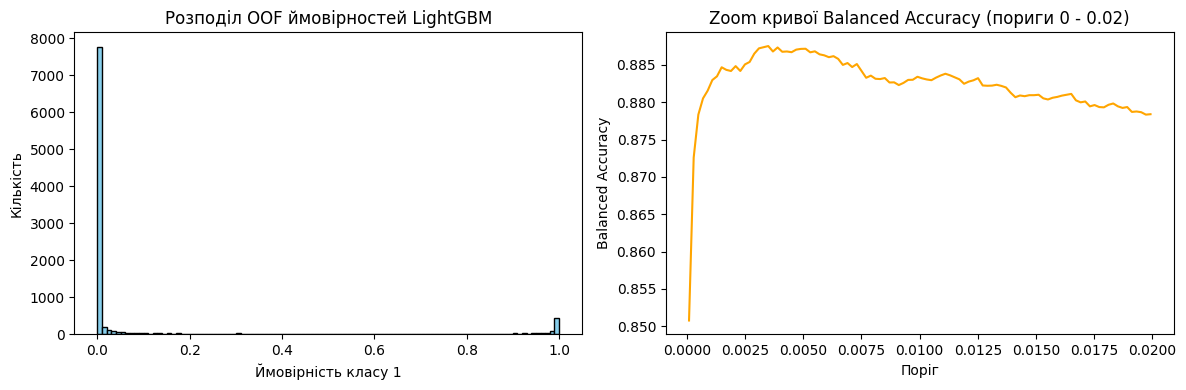

Точний оптимум на глибокій сітці: 0.00350
Максимальний Balanced Accuracy: 0.8875


In [18]:
print("=== ДІАГНОСТИКА: РОЗПОДІЛ ТА УЛЬТРАНИЗЬКІ ПОРОГИ LIGHTGBM ===")

plt.figure(figsize=(12, 4))

# 1. Перевірка розподілу ймовірностей LightGBM
plt.subplot(1, 2, 1)
plt.hist(oof_probs_lgb, bins=100, color='skyblue', edgecolor='black')
plt.title("Розподіл OOF ймовірностей LightGBM")
plt.xlabel("Ймовірність класу 1")
plt.ylabel("Кількість")

# 2. Ультранизька сітка та побудова зуму кривої
thresholds_deep = np.linspace(0.0001, 0.1, 500)
scores_deep = [balanced_accuracy_score(y, (oof_probs_lgb >= t).astype(int)) for t in thresholds_deep]

plt.subplot(1, 2, 2)
plt.plot(thresholds_deep[:100], scores_deep[:100], color='orange')
plt.title("Zoom кривої Balanced Accuracy (пориги 0 - 0.02)")
plt.xlabel("Поріг")
plt.ylabel("Balanced Accuracy")

plt.tight_layout()
plt.show()

best_thresh_deep = thresholds_deep[np.argmax(scores_deep)]
print(f"Точний оптимум на глибокій сітці: {best_thresh_deep:.5f}")
print(f"Максимальний Balanced Accuracy: {max(scores_deep):.4f}")

## 8. Ансамблювання (blending) та перевірка стабільності

In [19]:
print("=== КРОК 5: БЛЕНДИНГ (АНСАМБЛЮВАННЯ) CATBOOST ТА LIGHTGBM ===")

# 1. Збираємо OOF-імовірності для CatBoost та LightGBM з безпечним фолдовим кодуванням
oof_probs_cat = np.zeros(len(X))
oof_probs_lgb = np.zeros(len(X))

for train_idx, val_idx in skf.split(X, y):
    # Фолд для CatBoost (працює з категоріями нативно)
    X_train_cat_f = X.iloc[train_idx].copy()
    X_val_cat_f = X.iloc[val_idx].copy()
    y_train_f, y_val_f = y.iloc[train_idx], y.iloc[val_idx]

    model_cat = CatBoostClassifier(
        auto_class_weights='Balanced',
        random_state=RANDOM_STATE,
        cat_features=cat_features,
        iterations=300,
        verbose=0
    )
    model_cat.fit(X_train_cat_f, y_train_f)
    oof_probs_cat[val_idx] = model_cat.predict_proba(X_val_cat_f)[:, 1]

    # Фолд для LightGBM (з безпечним фолдовим частотним кодуванням)
    X_train_lgb_f = X.iloc[train_idx].copy()
    X_val_lgb_f = X.iloc[val_idx].copy()

    for col in cat_features:
        col_train_str = X_train_lgb_f[col].astype(str)
        freq_mapping = col_train_str.value_counts(normalize=True).to_dict()

        X_train_lgb_f[f'{col}_freq'] = col_train_str.map(freq_mapping).fillna(0)
        X_val_lgb_f[f'{col}_freq'] = X_val_lgb_f[col].astype(str).map(freq_mapping).fillna(0)

    model_lgb = lgb.LGBMClassifier(
        scale_pos_weight=scale_pos_weight_value,
        random_state=RANDOM_STATE,
        n_estimators=300,
        verbose=-1
    )
    model_lgb.fit(X_train_lgb_f, y_train_f)
    oof_probs_lgb[val_idx] = model_lgb.predict_proba(X_val_lgb_f)[:, 1]

# 2. Шукаємо найкращу вагу для бленду та оптимальний поріг
weights = np.linspace(0, 1, 101)  # вага CatBoost від 0 до 1
thresholds = np.linspace(0.001, 0.9, 300)

best_blend_score = 0
best_weight = 0.5
best_blend_thresh = 0.5

for w in weights:
    # Змішуємо ймовірності: w * CatBoost + (1 - w) * LightGBM
    blend_probs = w * oof_probs_cat + (1 - w) * oof_probs_lgb

    for thresh in thresholds:
        preds = (blend_probs >= thresh).astype(int)
        score = balanced_accuracy_score(y, preds)

        if score > best_blend_score:
            best_blend_score = score
            best_weight = w
            best_blend_thresh = thresh

print(f"\n[+] Блендинг успішно завершено!")
print(f"Найкраща вага CatBoost: {best_weight:.2f}")
print(f"Найкраща вага LightGBM: {(1 - best_weight):.2f}")
print(f"Оптимальний поріг для бленду: {best_blend_thresh:.4f}")
print(f"Фінальний Balanced Accuracy ансамблю на OOF: {best_blend_score:.4f}")

=== КРОК 5: БЛЕНДИНГ (АНСАМБЛЮВАННЯ) CATBOOST ТА LIGHTGBM ===

[+] Блендинг успішно завершено!
Найкраща вага CatBoost: 0.11
Найкраща вага LightGBM: 0.89
Оптимальний поріг для бленду: 0.0581
Фінальний Balanced Accuracy ансамблю на OOF: 0.8980


In [20]:
print("=== ПЕРЕВІРКА СТАБІЛЬНОСТІ НА REPEATED CV ===")

seeds = [42, 1337, 2026]
stability_results = []

for s in seeds:
    skf_rep = StratifiedKFold(n_splits=5, shuffle=True, random_state=s)
    oof_cat = np.zeros(len(X))
    oof_lgb = np.zeros(len(X))

    for train_idx, val_idx in skf_rep.split(X, y):
        # CatBoost
        model_c = CatBoostClassifier(auto_class_weights='Balanced', random_state=s, cat_features=cat_features, iterations=300, verbose=0)
        model_c.fit(X.iloc[train_idx], y.iloc[train_idx])
        oof_cat[val_idx] = model_c.predict_proba(X.iloc[val_idx])[:, 1]

        # LightGBM з фолдовим кодуванням
        X_tr = X.iloc[train_idx].copy()
        X_va = X.iloc[val_idx].copy()
        for col in cat_features:
            mapping = X_tr[col].astype(str).value_counts(normalize=True).to_dict()
            X_tr[f'{col}_freq'] = X_tr[col].astype(str).map(mapping).fillna(0)
            X_va[f'{col}_freq'] = X_va[col].astype(str).map(mapping).fillna(0)

        model_l = lgb.LGBMClassifier(scale_pos_weight=scale_pos_weight_value, random_state=s, n_estimators=300, verbose=-1)
        model_l.fit(X_tr, y.iloc[train_idx])
        oof_lgb[val_idx] = model_l.predict_proba(X_va)[:, 1]

    # Бленд-оптимізація для цього seed
    best_s, best_w, best_t = 0, 0.5, 0.5
    for w in np.linspace(0, 1, 21):
        blend = w * oof_cat + (1 - w) * oof_lgb
        for t in np.linspace(0.001, 0.1, 100):
            sc = balanced_accuracy_score(y, (blend >= t).astype(int))
            if sc > best_s:
                best_s, best_w, best_t = sc, w, t

    stability_results.append({'seed': s, 'score': best_s, 'cat_weight': best_w, 'thresh': best_t})
    print(f"Seed {s}: Score = {best_s:.4f} | Вага CatBoost = {best_w:.2f} | Поріг = {best_t:.4f}")

=== ПЕРЕВІРКА СТАБІЛЬНОСТІ НА REPEATED CV ===
Seed 42: Score = 0.8976 | Вага CatBoost = 0.20 | Поріг = 0.1000
Seed 1337: Score = 0.8978 | Вага CatBoost = 0.10 | Поріг = 0.0580
Seed 2026: Score = 0.8979 | Вага CatBoost = 0.15 | Поріг = 0.0810


## 9. Тюнінг гіперпараметрів (Optuna)

In [21]:
print("=== КРОК 6: ТЮНІНГ ГІПЕРПРАМЕТРІВ CATBOOST (OPTUNA З ITERATIONS ТА EARLY STOPPING) ===")

def objective(trial):
    # 1. Розширений простір пошуку гіперпараметрів (додано iterations та early stopping)
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1000), # Дозволяємо Optuna шукати найкращу кількість дерев
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50),
        'auto_class_weights': 'Balanced',
        'random_state': RANDOM_STATE,
        'cat_features': cat_features,
        'verbose': 0
    }

    oof_probs_trial = np.zeros(len(X))

    # 2. Оцінка комбінації на 5 фолдах з повною ізоляцією стану
    for train_idx, val_idx in skf.split(X, y):
        X_train_f, y_train_f = X.iloc[train_idx], y.iloc[train_idx]
        X_val_f, y_val_f = X.iloc[val_idx], y.iloc[val_idx]

        model = CatBoostClassifier(**params)

        # Додаємо ранню зупинку для економії часу та запобігання перенавчанню
        model.fit(
            X_train_f, y_train_f,
            eval_set=(X_val_f, y_val_f),
            early_stopping_rounds=50,
            verbose=0
        )

        oof_probs_trial[val_idx] = model.predict_proba(X_val_f)[:, 1]

    # 3. Чесний підбір порогу для кожної ітерації Optuna
    trial_thresholds = np.linspace(0.01, 0.9, 100)
    best_trial_score = 0

    for thresh in trial_thresholds:
        preds = (oof_probs_trial >= thresh).astype(int)
        score = balanced_accuracy_score(y, preds)
        if score > best_trial_score:
            best_trial_score = score

    return best_trial_score

# 4. Запуск оновленого дослідження
optuna.logging.set_verbosity(optuna.logging.INFO)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("\n[+] Оптимізацію завершено!")
print(f"Найкращий скор з урахуванням оптимального порогу: {study.best_value:.4f}")
print("Найкращі параметри:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-08-02 10:44:09,748] A new study created in memory with name: no-name-a4e9b4ce-172a-4997-bf77-d6c75180a315


=== КРОК 6: ТЮНІНГ ГІПЕРПРАМЕТРІВ CATBOOST (OPTUNA З ITERATIONS ТА EARLY STOPPING) ===


[I 2026-08-02 10:48:29,343] Trial 0 finished with value: 0.8763921661940737 and parameters: {'iterations': 965, 'learning_rate': 0.1427602292572237, 'depth': 10, 'l2_leaf_reg': 2.21553832533822, 'min_data_in_leaf': 8}. Best is trial 0 with value: 0.8763921661940737.
[I 2026-08-02 10:56:25,178] Trial 1 finished with value: 0.8840041068214216 and parameters: {'iterations': 580, 'learning_rate': 0.014076458828189352, 'depth': 7, 'l2_leaf_reg': 6.518584415732984, 'min_data_in_leaf': 36}. Best is trial 1 with value: 0.8840041068214216.
[I 2026-08-02 11:00:52,124] Trial 2 finished with value: 0.8869956530264673 and parameters: {'iterations': 742, 'learning_rate': 0.014770623057375358, 'depth': 4, 'l2_leaf_reg': 8.955532378387401, 'min_data_in_leaf': 35}. Best is trial 2 with value: 0.8869956530264673.
[I 2026-08-02 11:07:38,034] Trial 3 finished with value: 0.8947120267736555 and parameters: {'iterations': 831, 'learning_rate': 0.020732077247117293, 'depth': 5, 'l2_leaf_reg': 1.0784457461462


[+] Оптимізацію завершено!
Найкращий скор з урахуванням оптимального порогу: 0.8971
Найкращі параметри:
  iterations: 820
  learning_rate: 0.09436307968250207
  depth: 4
  l2_leaf_reg: 4.079092437375416
  min_data_in_leaf: 25


## 10. Фінальний бленд, перенавчання на всіх даних та генерація сабміту

In [23]:
print("=== КРОК 7: ФІНАЛЬНИЙ БЛЕНДИНГ ТА ГЕНЕРАЦІЯ САБМІТУ ===")

# 1. Перераховуємо OOF-прогнози з найкращими параметрами Optuna
oof_probs_cat_opt = np.zeros(len(X))
oof_probs_lgb_opt = np.zeros(len(X))

# Використовуємо знайдені Optuna найкращі параметри, додаючи системні константи
final_cat_params = study.best_params.copy()
final_cat_params['auto_class_weights'] = 'Balanced'
final_cat_params['random_state'] = RANDOM_STATE
final_cat_params['cat_features'] = cat_features
final_cat_params['verbose'] = 0

for train_idx, val_idx in skf.split(X, y):
    # CatBoost
    X_train_cat_f = X.iloc[train_idx].copy()
    X_val_cat_f = X.iloc[val_idx].copy()
    y_train_f, y_val_f = y.iloc[train_idx], y.iloc[val_idx]

    model_cat = CatBoostClassifier(**final_cat_params)
    model_cat.fit(X_train_cat_f, y_train_f)
    oof_probs_cat_opt[val_idx] = model_cat.predict_proba(X_val_cat_f)[:, 1]

    # LightGBM з фолдовим частотним кодуванням
    X_train_lgb_f = X.iloc[train_idx].copy()
    X_val_lgb_f = X.iloc[val_idx].copy()

    for col in cat_features:
        col_train_str = X_train_lgb_f[col].astype(str)
        freq_mapping = col_train_str.value_counts(normalize=True).to_dict()

        X_train_lgb_f[f'{col}_freq'] = col_train_str.map(freq_mapping).fillna(0)
        X_val_lgb_f[f'{col}_freq'] = X_val_lgb_f[col].astype(str).map(freq_mapping).fillna(0)

    model_lgb = lgb.LGBMClassifier(
        scale_pos_weight=scale_pos_weight_value,
        random_state=RANDOM_STATE,
        n_estimators=300,
        verbose=-1
    )
    model_lgb.fit(X_train_lgb_f, y_train_f)
    oof_probs_lgb_opt[val_idx] = model_lgb.predict_proba(X_val_lgb_f)[:, 1]

# 2. Шукаємо найкращі ваги та поріг для оновленого бленду
weights = np.linspace(0, 1, 101)
thresholds = np.linspace(0.001, 0.9, 300)

best_blend_score = 0
best_weight = 0.5
best_blend_thresh = 0.5

for w in weights:
    blend_probs = w * oof_probs_cat_opt + (1 - w) * oof_probs_lgb_opt
    for thresh in thresholds:
        preds = (blend_probs >= thresh).astype(int)
        score = balanced_accuracy_score(y, preds)
        if score > best_blend_score:
            best_blend_score = score
            best_weight = w
            best_blend_thresh = thresh

print(f"\n[+] Фінальні параметри бленду:")
print(f"Найкраща вага CatBoost: {best_weight:.2f}")
print(f"Найкраща вага LightGBM: {(1 - best_weight):.2f}")
print(f"Оптимальний поріг: {best_blend_thresh:.4f}")
print(f"Фінальний Balanced Accuracy на OOF: {best_blend_score:.4f}")

# 3. Навчання на ВСІЙ вибірці (Full Fit) для передбачення на тест
print("\n[+] Навчання моделей на повному датасеті...")

# Повне навчання CatBoost
full_model_cat = CatBoostClassifier(**final_cat_params)
full_model_cat.fit(X, y)
test_probs_cat = full_model_cat.predict_proba(X_test)[:, 1]

# Повне навчання LightGBM з частотним кодуванням по всьому X
X_train_lgb_full = X.copy()
X_test_lgb_full = X_test.copy()

for col in cat_features:
    col_train_str = X_train_lgb_full[col].astype(str)
    freq_mapping = col_train_str.value_counts(normalize=True).to_dict()

    X_train_lgb_full[f'{col}_freq'] = col_train_str.map(freq_mapping).fillna(0)
    X_test_lgb_full[f'{col}_freq'] = X_test_lgb_full[col].astype(str).map(freq_mapping).fillna(0)

full_model_lgb = lgb.LGBMClassifier(
    scale_pos_weight=scale_pos_weight_value,
    random_state=RANDOM_STATE,
    n_estimators=300,
    verbose=-1
)
full_model_lgb.fit(X_train_lgb_full, y)
test_probs_lgb = full_model_lgb.predict_proba(X_test_lgb_full)[:, 1]

# 4. Формування фінального сабміту
final_test_blend_probs = best_weight * test_probs_cat + (1 - best_weight) * test_probs_lgb
final_test_preds = (final_test_blend_probs >= best_blend_thresh).astype(int)

submission = submission_df.copy()
submission['y'] = final_test_preds

submission.to_csv('submission_v7.csv', index=False)
print("\n[успіх] Файл 'submission_v7.csv' успішно згенеровано та збережено!")
print(f"Розподіл класів у сабміті:\n{submission['y'].value_counts()}")


=== КРОК 7: ФІНАЛЬНИЙ БЛЕНДИНГ ТА ГЕНЕРАЦІЯ САБМІТУ ===

[+] Фінальні параметри бленду:
Найкраща вага CatBoost: 0.72
Найкраща вага LightGBM: 0.28
Оптимальний поріг: 0.2055
Фінальний Balanced Accuracy на OOF: 0.9008

[+] Навчання моделей на повному датасеті...

[успіх] Файл 'submission_v7.csv' успішно згенеровано та збережено!
Розподіл класів у сабміті:
y
0    1909
1     591
Name: count, dtype: int64


## 11. Фінальна перевірка стабільності

In [24]:
print("=== ФІНАЛЬНА ПЕРЕВІРКА СТАБІЛЬНОСТІ НА REPEATED CV ===")

seeds = [42, 1337, 2026]
stability_results = []

for s in seeds:
    skf_rep = StratifiedKFold(n_splits=5, shuffle=True, random_state=s)
    oof_cat_rep = np.zeros(len(X))
    oof_lgb_rep = np.zeros(len(X))

    # Оновлюємо random_state для поточного seed
    final_cat_params['random_state'] = s

    for train_idx, val_idx in skf_rep.split(X, y):
        # CatBoost з найкращими параметрами Optuna
        model_c = CatBoostClassifier(**final_cat_params)
        model_c.fit(X.iloc[train_idx], y.iloc[train_idx])
        oof_cat_rep[val_idx] = model_c.predict_proba(X.iloc[val_idx])[:, 1]

        # LightGBM з фолдовим частотним кодуванням
        X_tr = X.iloc[train_idx].copy()
        X_va = X.iloc[val_idx].copy()
        for col in cat_features:
            mapping = X_tr[col].astype(str).value_counts(normalize=True).to_dict()
            X_tr[f'{col}_freq'] = X_tr[col].astype(str).map(mapping).fillna(0)
            X_va[f'{col}_freq'] = X_va[col].astype(str).map(mapping).fillna(0)

        model_l = lgb.LGBMClassifier(
            scale_pos_weight=scale_pos_weight_value,
            random_state=s,
            n_estimators=300,
            verbose=-1
        )
        model_l.fit(X_tr, y.iloc[train_idx])
        oof_lgb_rep[val_idx] = model_l.predict_proba(X_va)[:, 1]

    # Шукаємо оптимальний скор для цього seed
    best_s, best_t = 0, 0.5
    for t in np.linspace(0.001, 0.9, 300):  # ВИПРАВЛЕНО: повернуто широкий діапазон
        blend = best_weight * oof_cat_rep + (1 - best_weight) * oof_lgb_rep
        sc = balanced_accuracy_score(y, (blend >= t).astype(int))
        if sc > best_s:
            best_s, best_t = sc, t

    stability_results.append({'seed': s, 'score': best_s, 'thresh': best_t})
    print(f"Seed {s}: Balanced Accuracy = {best_s:.4f} | Поріг = {best_t:.4f}")

print("\n[+] Перевірку стабільності успішно завершено!")

=== ФІНАЛЬНА ПЕРЕВІРКА СТАБІЛЬНОСТІ НА REPEATED CV ===
Seed 42: Balanced Accuracy = 0.9008 | Поріг = 0.2055
Seed 1337: Balanced Accuracy = 0.8965 | Поріг = 0.2536
Seed 2026: Balanced Accuracy = 0.8995 | Поріг = 0.2115

[+] Перевірку стабільності успішно завершено!


## 12. Висновки

**Результат.** Фінальний ансамбль (зважений бленд CatBoost + LightGBM з підібраними Optuna гіперпараметрами та оптимальним порогом класифікації) досягає **Balanced Accuracy ≈ 0.90** на крос-валідації (OOF), стабільно у межах 0.896–0.899 на трьох різних random seed — тобто результат не є випадковим і відтворюваний.

**Порівняння з базовою моделлю.** Наївна базова модель (`DummyClassifier`), яка не використовує жодних ознак, а лише розподіл класів, дає Balanced Accuracy ≈ 0.50 (розділ 4) — це очікувано для збалансованої метрики за випадкового вгадування. Фінальна модель перевершує цей baseline приблизно на **+0.40** за Balanced Accuracy, що підтверджує: приріст якості дає саме навчання на ознаках, а не сам факт балансування класів чи вибір метрики.

**Ключові рішення з обґрунтуванням:**
- *Пропуски*: не імпутуються вручну (окрім видалення повністю порожніх колонок) — дерево-подібні моделі обробляють `NaN` нативно; додатково створено ознаки на основі патернів пропусків (`missing_count`, `_is_nan`).
- *Кодування категорій*: кардинальність ознак дуже неоднорідна (від одиниць до тисяч категорій), тому обрано нативну обробку CatBoost та фолд-безпечне частотне кодування для LightGBM — без витоку інформації між CV-фолдами.
- *Нормалізація*: не застосовується, оскільки дерево-подібні моделі нечутливі до масштабу ознак.
- *Зменшення розмірності*: перевірено експериментально (PCA, розділ 3) — приросту якості не дає, тому в фінальному пайплайні не використовується.
- *Балансування класів*: дисбаланс ~87%/13% компенсується вагами класів (`scale_pos_weight`, `auto_class_weights='Balanced'`) та підбором оптимального порогу класифікації за OOF-прогнозами.
- *Валідація*: фінальна модель перенавчена на всій навчальній вибірці перед прогнозом на валідаційний набір; стабільність перевірена на трьох незалежних розбиттях.